In [25]:
import numpy as pd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# # Load Dataset

In [3]:
df = pd.read_csv("compact.csv", parse_dates=['date'])

# # Exploratory Data

In [4]:
df.isna().sum()
df.country.unique()
df.shape
df.date.max()
df.date.min()
df.describe()

,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,new_deaths_smoothed,...,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand,human_development_index
count,591522,5.791740e+05,5.748980e+05,5.736890e+05,579174.000000,574898.000000,573689.000000,5.791740e+05,576007.000000,574795.000000,...,5.735000e+05,564193.000000,566522.000000,568848.000000,474397.000000,379785.000000,497681.000000,287559.000000,402869.000000,0.0
mean,2023-03-01 14:42:40.865022,1.495616e+07,9.460280e+03,9.480267e+03,138028.366617,88.701426,88.891886,1.601894e+05,90.470208,90.662862,...,1.318604e+08,371.461117,31.153797,73.438377,27635.624601,13.690381,10.101276,62.385072,3.004089,NaN
min,2020-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,5.130000e+02,0.136470,14.298000,18.817699,1051.259277,0.000000,1.500000,3.487560,0.150000,NaN
25%,2021-07-30 00:00:00,1.018900e+04,0.000000e+00,0.000000e+00,3780.181225,0.000000,0.000000,8.500000e+01,0.000000,0.000000,...,4.553740e+05,36.265862,22.243999,68.748703,6871.124512,0.413263,6.500000,28.407530,1.110000,NaN
50%,2023-02-22 00:00:00,9.239350e+04,0.000000e+00,2.285714e+00,56868.240000,0.000000,0.352183,1.104000e+03,0.000000,0.000000,...,6.035104e+06,92.084663,31.683001,74.695999,18477.214844,2.436315,8.600000,72.116234,2.410000,NaN
75%,2024-10-01 00:00:00,1.153361e+06,3.300000e+01,1.368571e+02,215842.230000,3.606188,22.420507,1.393100e+04,0.000000,1.285714,...,2.971544e+07,237.470367,39.080002,78.768799,42829.199219,19.495604,12.100000,91.757347,3.970000,NaN
max,2026-05-17 00:00:00,7.791355e+08,8.401906e+06,6.402033e+06,769806.800000,230762.550000,37463.746000,7.114321e+06,57167.000000,14820.714000,...,8.021407e+09,21344.242188,59.875000,85.746399,132569.531250,85.317673,31.400000,100.000000,21.990000,NaN
std,NaN,7.636277e+07,1.111743e+05,9.494594e+04,179296.580994,927.874303,478.529423,7.947452e+05,762.193143,702.015464,...,6.695555e+08,1688.706134,9.666358,7.656049,26706.205558,20.818537,5.425728,31.283794,2.739255,NaN


# # Cleaning Data

In [5]:
features = ["country", "date", "total_cases", "new_cases", "total_deaths", "new_deaths", "population"]
df = df[features]
df = df.fillna(0)
df.head()

,country,date,total_cases,new_cases,total_deaths,new_deaths,population
0,Afghanistan,2020-01-01,0.0,0.0,0.0,0.0,40578847.0
1,Afghanistan,2020-01-02,0.0,0.0,0.0,0.0,40578847.0
2,Afghanistan,2020-01-03,0.0,0.0,0.0,0.0,40578847.0
3,Afghanistan,2020-01-04,0.0,0.0,0.0,0.0,40578847.0
4,Afghanistan,2020-01-05,0.0,0.0,0.0,0.0,40578847.0


# # Filter countries

In [18]:
countries = ["United States", "India", "Brazil", "United Kingdom"]
df = df[df.country.isin(countries)]
df[df.country == "Brazil"]

,country,date,total_cases,new_cases,total_deaths,new_deaths,population,month,death rate
72175,Brazil,2020-01-01,0.0,0.0,0.0,0.0,210306411.0,2020-01,NaN
72176,Brazil,2020-01-02,0.0,0.0,0.0,0.0,210306411.0,2020-01,NaN
72177,Brazil,2020-01-03,0.0,0.0,0.0,0.0,210306411.0,2020-01,NaN
72178,Brazil,2020-01-04,0.0,0.0,0.0,0.0,210306411.0,2020-01,NaN
72179,Brazil,2020-01-05,0.0,0.0,0.0,0.0,210306411.0,2020-01,NaN
...,...,...,...,...,...,...,...,...,...
74499,Brazil,2026-05-13,38024465.0,0.0,703961.0,0.0,210306411.0,2026-05,1.851337
74500,Brazil,2026-05-14,38024465.0,0.0,703961.0,0.0,210306411.0,2026-05,1.851337
74501,Brazil,2026-05-15,38024465.0,0.0,703961.0,0.0,210306411.0,2026-05,1.851337
74502,Brazil,2026-05-16,38024465.0,0.0,703961.0,0.0,210306411.0,2026-05,1.851337


# # Monthly aggregate
Identify monthly cases per country

In [7]:
df["month"] = df.date.dt.to_period("M")
monthly = df.groupby(["country", "month"]).new_cases.sum()
df.groupby("country").total_cases.sum()

country
Brazil            6.495417e+10
India             8.153874e+10
United Kingdom    4.115601e+10
United States     1.735187e+11
Name: total_cases, dtype: float64

# # Calculate death rate

In [ ]:
df["death rate"] = (df.total_deaths / df.total_cases) * 100
df

# # Visualization

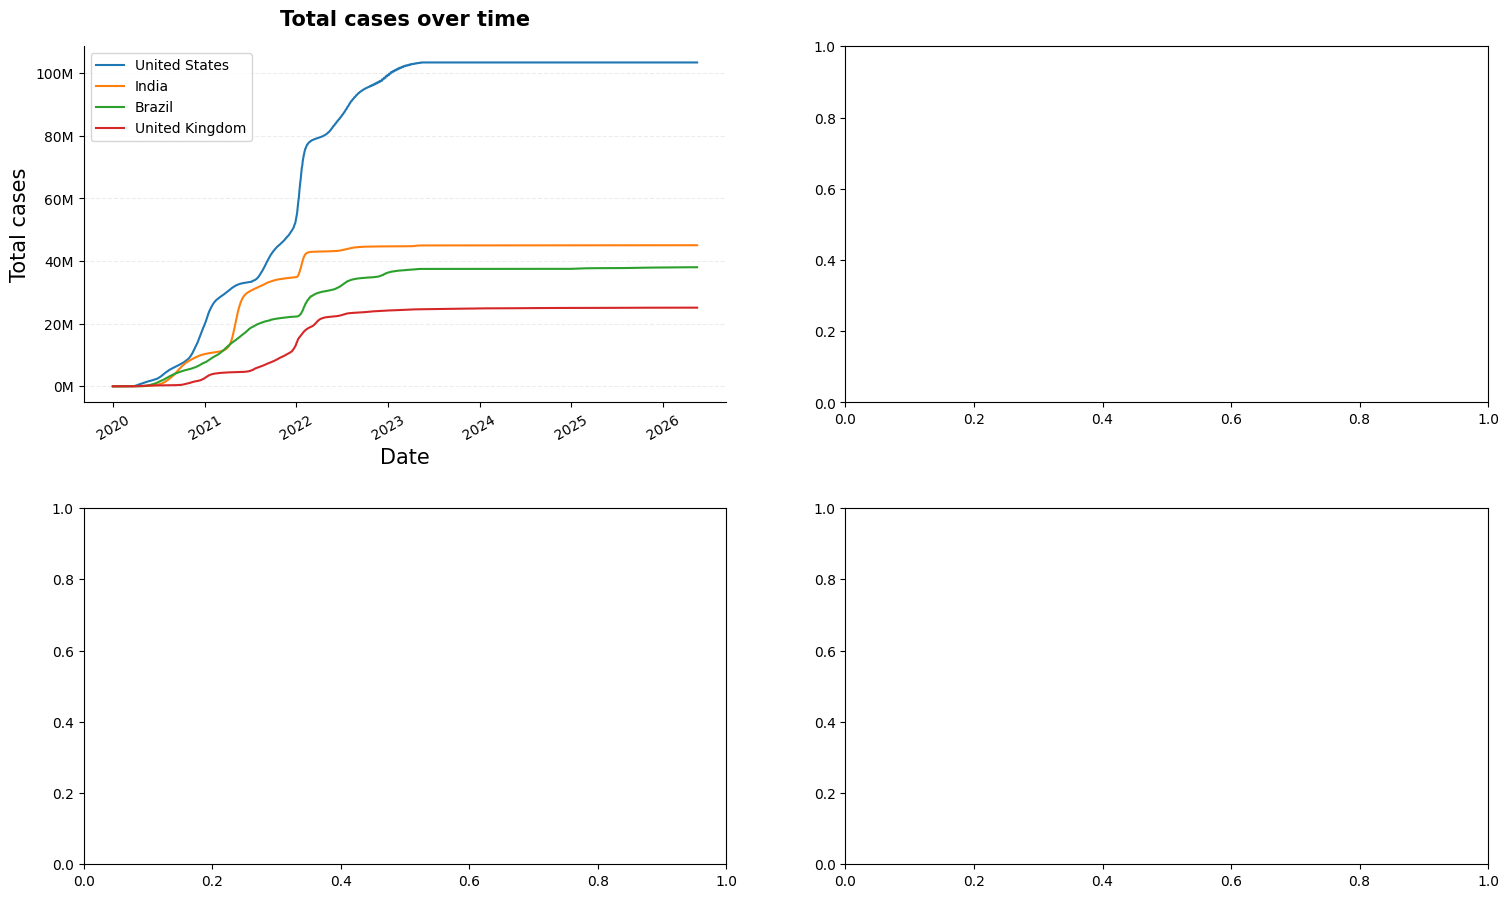

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
plt.tight_layout(pad=5.5)
# separates axis
ax1 = axes[0, 0]
ax2 = axes[0, 1]
ax3 = axes[1, 0]
ax4 = axes[1, 1]

# Line chart (Total cases over time per country)
for country in countries:
    country_df = df[df["country"] == country]
    ax1.plot(country_df.date, country_df.total_cases, label=country)

# add styles and text
ax1.set_title("Total cases over time", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("Date", fontsize=15)
ax1.set_ylabel("Total cases", fontsize=15)
ax1.spines[["top", "right"]].set_visible(False)
ax1.tick_params(axis="x", rotation=30)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _ : f"{x/1e6:.0f}M")
)
ax1.grid(axis='y', linestyle="--", alpha=0.23)
ax1.legend()

plt.show()